# Various Gradient Descent - Sklearn vs Custom Code Comparison using Python

1. Loading Required Libraries and Dataset
    - Working with the Diabetes dataset
    - Splitting the dataset
2. Necessary Variable Initialization and Functions to Plot
    - Initialize variables for model comparison metric logging
    - Creating unified plotting functions to eliminate redundant code
3. Ordinary Least Squares vs. Batch Gradient Descent
    - Using Sklearn LinearRegression() (Analytical OLS Baseline)
    - Using Custom Batch Gradient Descent code written from scratch
    - Performance comparison via prediction scatter plots
4. Stochastic Gradient Descent (SGD)
    - Using Sklearn SGDRegressor()
    - Using Custom Stochastic GD code written from scratch
    - Performance comparison via prediction scatter plots
5. Mini-Batch Gradient Descent
    - Using Sklearn SGDRegressor() with partial_fit() loops
    - Using Custom Mini-Batch GD code written from scratch
    - Performance comparison via prediction scatter plots
6. System Performance Matrix & Residual Analysis
    - Comparing R² Scores and Execution Efficiency (Time in Seconds)
    - Visualizing the Error Landscape using Residual Boxplots

## Loading Required Libraries and Dataset

In [1]:
# Loading Necesssary Libraries and packages

import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import random
import time

Loading Datasets and splitting for training and testing

In [2]:
X,y = load_diabetes(return_X_y = True)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state=7) 

##  Necessary Variable Initialization and Functions to Plot


In [4]:
# Initialize  performance tracker
performance_data = {
    "Model Name": [],
    "Execution Time (s)": [],
    "R² Score": []
}

def log_performance(name, exec_time, r2_score):
    performance_data["Model Name"].append(name)
    performance_data["Execution Time (s)"].append(exec_time)
    performance_data["R² Score"].append(r2_score)

In [5]:
# side-by-side scatter plots comparing Sklearn and Custom model predictions.

def plot_comparison(y_test, sklearn_pred, custom_pred, title_suffix):
   
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Generate the perfect-fit 45-degree reference line
#     When we  plot the line using plt.plot(perfect_line, perfect_line), 
#  we  are telling matplotlib that for every single point on this line, the X value is exactly equal to the Y value
# ($Y = X$).

    perfect_line = np.linspace(min(y_test), max(y_test), 100)
    
    # 1. Sklearn Plot
    sns.scatterplot(x=y_test, y=sklearn_pred, alpha=0.6, color="teal", ax=ax1)
    ax1.plot(perfect_line, perfect_line, color="red", linestyle="--", linewidth=2, label="Perfect Fit")
    ax1.set_title(f"Sklearn {title_suffix}", fontsize=13, weight='bold', pad=10)
    ax1.set_xlabel("Actual Values", fontsize=11)
    ax1.set_ylabel("Predicted Values ($\hat{y}$)", fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Custom Plot
    sns.scatterplot(x=y_test, y=custom_pred, alpha=0.6, color="purple", ax=ax2)
    ax2.plot(perfect_line, perfect_line, color="red", linestyle="--", linewidth=2, label="Perfect Fit")
    ax2.set_title(f"Custom {title_suffix}", fontsize=13, weight='bold', pad=10)
    ax2.set_xlabel("Actual Values", fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Ordinary Least Squares vs. Batch Gradient Descent

#### Using Sk-learn OLS

In [6]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
start_time = time.time()
reg.fit(X_train, y_train)
exec_time = time.time()-start_time
y_pred_sk = reg.predict(X_test)
r2_score_regsk =r2_score(y_test, y_pred_sk)

log_performance("Sklearn OLS (Batch)", exec_time, r2_score_regsk)

print(f"Cofficients: {reg.coef_}")
print('___________')
print(f"Intercept: {reg.intercept_}")

Cofficients: [ -64.48266901 -258.05630216  522.45175182  354.25646469 -950.91543697
  649.27682123  111.90693136   83.49837069  865.55459623   41.2675983 ]
___________
Intercept: 152.47070653856179


#### Custom Batch Gradient Descent code written from scratch

In [7]:
class BatchGDRegressor:
    def __init__(self, learning_rate = 0.01, epochs = 1000):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
    
    def fit(self, X_train, y_train):
        # Init coficent
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            y_hat = np.dot(X_train, self.coef_)+self.intercept_
            
            # Updating Intercept
            intercept_derivation = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr* intercept_derivation)
        
            # Updating Cofficeint:
            cofficent_derivation = -2 * np.dot((y_train - y_hat), X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr* cofficent_derivation)
#         print(self.coef_)
#         print('___________')
#         print(self.intercept_)
#         print('___________')
            
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [8]:
obj = BatchGDRegressor(learning_rate=0.1, epochs=1500)

start_time = time.time()
obj.fit(X_train, y_train)
exec_time = time.time()-start_time
y_pred_cust = obj.predict(X_test)
r2_score_batchgdg = r2_score(y_test, y_pred_cust)

# print(f"Cofficients: {obj.coef_}")
# print('___________')
# print(f"Intercept: {obj.intercept_}")

In [9]:
log_performance("Custom Batch GD", exec_time, r2_score_batchgdg) 

#### Comparison via prediction scatter plots

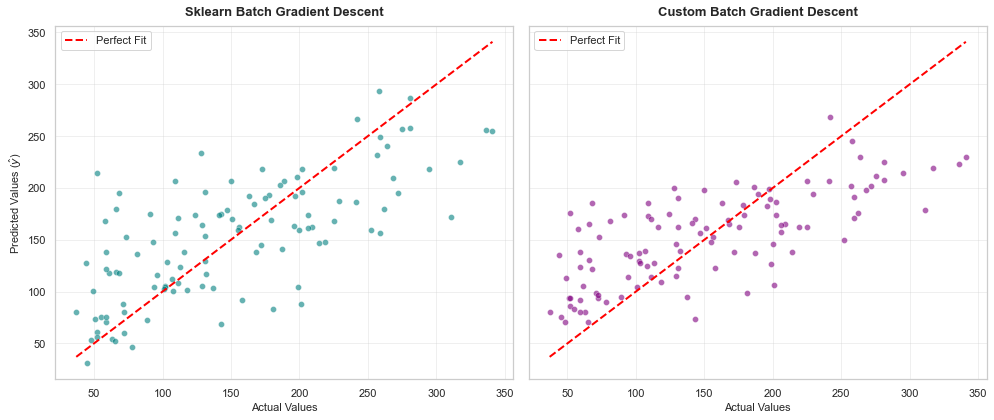

In [10]:
plot_comparison(y_test, y_pred_sk, y_pred_cust, "Batch Gradient Descent")

# Stochastic Gradient Descent (SGD)


#### Using Sklearn SGDRegressor()

In [11]:


reg = SGDRegressor(max_iter=100, learning_rate='constant', eta0=0.1)
start_time = time.time()
reg.fit(X_train , y_train)
exec_time = time.time() - start_time
y_pred_sk_sgd= reg.predict(X_test)
r2_sdg_sk = r2_score(y_test, y_pred_sk_sgd)

print('___________')
print(f"Cofficients: {reg.coef_}")
print('___________')
print(f"Intercept: {reg.intercept_}")

___________
Cofficients: [ -11.74310001 -171.30295213  437.29090591  298.61231438  -17.15511492
  -84.842062   -193.48522681  114.21787428  394.70448345  105.17257518]
___________
Intercept: [157.36578761]


In [12]:
log_performance("Sklearn Stochastic GD", exec_time, r2_sdg_sk)

#### Using Custom Stochastic GD code written from scratch## Coading from Scratch

In [13]:
class StochasticGDRegressor:
    def __init__(self, learning_rate = 0.01, epochs = 100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
    
    def fit(self, X_train, y_train):
        # Init coficent
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        num_samples = X_train.shape[0]
        
        for i in range(self.epochs):
            ind = np.arange(num_samples)
            np.random.shuffle(ind)
            for j in ind:
                y_hat = np.dot(X_train[j], self.coef_) + self.intercept_
                err = y_train[j]-y_hat
                
                # Updating Intercept
                intercept_derivation = -2 * err #no mean to be calculated because y_hat is just a single number
                self.intercept_ = self.intercept_ - (self.lr* intercept_derivation)

                # Updating Cofficeint:
                cofficent_derivation = -2 * np.dot(err, X_train[j])
                self.coef_ = self.coef_ - (self.lr* cofficent_derivation)
        
#         print(self.coef_)
#         print('___________')
#         print(self.intercept_)
#         print('___________')
            
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [14]:
obj = StochasticGDRegressor(learning_rate = 0.1, epochs = 1000)
start_time = time.time()
obj.fit(X_train, y_train)
exec_time = time.time() - start_time

y_pred_cust_sgd = obj.predict(X_test)
r2_sgd_custom  = r2_score(y_test, y_pred_cust_sgd)

In [15]:
log_performance("Custom Stochastic GD", exec_time, r2_sgd_custom)

#### Comparison via prediction scatter plots

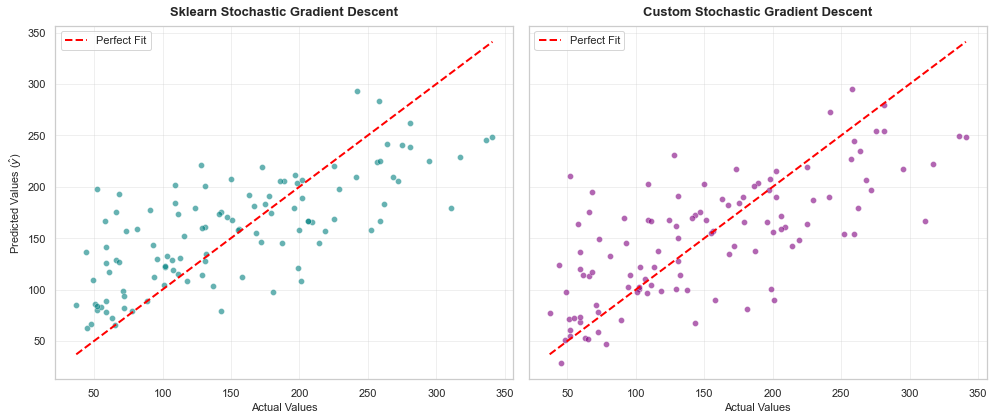

In [16]:
plot_comparison(y_test, y_pred_sk_sgd, y_pred_cust_sgd, "Stochastic Gradient Descent")

# Mini-Batch Gradient Decent


#### Using Sklearn SGDRegressor() with partial_fit() loops

In [17]:
reg = SGDRegressor(learning_rate='constant', eta0=0.1)
start_time = time.time()

batchsize = 35 

for i in range(100):
    sample = random.sample(range(X_train.shape[0]), batchsize)
    reg.partial_fit(X_train[sample] , y_train[sample])
exec_time = time.time() - start_time

y_pred_mbgd_sk = reg.predict(X_test)
r2_mbgd_sk = r2_score(y_test, y_pred_mbgd_sk)

In [18]:
log_performance("Sklearn Mini-Batch GD", exec_time, r2_mbgd_sk)

#### Using Custom Mini-Batch GD code written from scratch

In [19]:
class MiniBatchGDRegressor:
    def __init__(self, batch_size, learning_rate = 0.01, epochs = 100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
    
    def fit(self, X_train, y_train):
        # Init coficent
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            for j in range(int(X_train.shape[0]/self.batch_size)):
                sample = random.sample(range(X_train.shape[0]), self.batch_size)
                
                y_hat = np.dot(X_train[sample], self.coef_) + self.intercept_
                
                # Updating Intercept
                intercept_derivation = -2 * np.mean(y_train[sample] - y_hat) 
                self.intercept_ = self.intercept_ - (self.lr* intercept_derivation)

                # Updating Cofficeint:
                cofficent_derivation = -2 * np.dot((y_train[sample] - y_hat), X_train[sample])/ self.batch_size
                self.coef_ = self.coef_ - (self.lr* cofficent_derivation)
                
    
            
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [20]:
# mbgd = MiniBatchGDRegressor(batch_size = int(X_train.shape[0]/15), learning_rate=0.5 , epochs=15000)
mbgd = MiniBatchGDRegressor(batch_size = 35, learning_rate=0.055 , epochs=1000)

start_time = time.time()
mbgd.fit(X_train, y_train)
exec_time = time.time() - start_time

y_predy_mbgd_cust = mbgd.predict(X_test)
r2_mbgd_cust = r2_score(y_test, y_predy_mbgd_cust)

In [21]:
log_performance("Custom Mini-Batch GD", exec_time, r2_mbgd_cust)

#### Comparison via prediction scatter plots

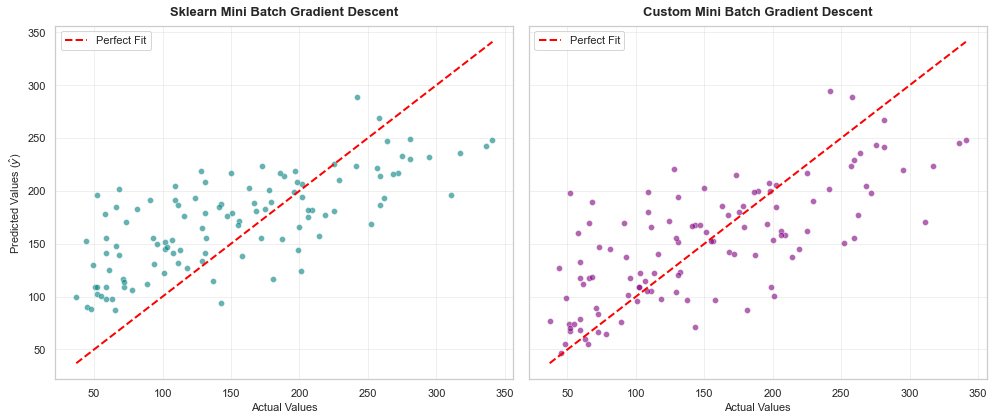

In [22]:
plot_comparison(y_test, y_pred_mbgd_sk, y_predy_mbgd_cust, "Mini Batch Gradient Descent")

## Model Performance Matrix & Residual Analysis

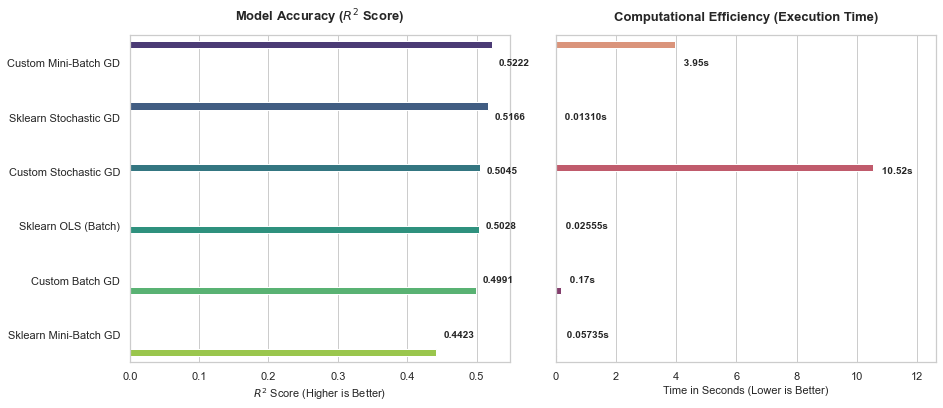

In [23]:
# Extracting data directly from evaluation dataframe
df = pd.DataFrame(performance_data)
sns.set_theme(style="whitegrid")

#  Sort by R² Score descending so BOTH subplots share the exact same vertical order
df_sorted = df.sort_values(by="R² Score", ascending=False).reset_index(drop=True)

# Initialize side-by-side subplots (1 row, 2 columns) with shared vertical axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Panel 1: R² Score Plot 

sns.barplot(x="R² Score", y="Model Name", data=df_sorted, ax=ax1, palette="viridis", hue="Model Name")
ax1.set_title("Model Accuracy ($R^2$ Score)", fontsize=13, pad=15, weight='bold')
ax1.set_xlabel("$R^2$ Score (Higher is Better)", fontsize=11)
ax1.set_ylabel("") 


if ax1.get_legend() is not None:
    ax1.get_legend().remove()

# Label values directly onto the bars cleanly
for index, row in df_sorted.iterrows():
    val = row["R² Score"]
    if val >= 0:
        ax1.text(val + 0.01, index, f"{val:.4f}", va='center', ha='left', weight='bold', fontsize=10)
    else:
        # If the value is negative, print it safely at the start of the baseline
        ax1.text(0.01, index, f"{val:.4f} (Failed)", va='center', ha='left', weight='bold', fontsize=10, color='crimson')


# Panel 2: Execution Time Plot

sns.barplot(x="Execution Time (s)", y="Model Name", data=df_sorted, ax=ax2, palette="flare", hue="Model Name")
ax2.set_title("Computational Efficiency (Execution Time)", fontsize=13, pad=15, weight='bold')
ax2.set_xlabel("Time in Seconds (Lower is Better)", fontsize=11)
ax2.set_ylabel("") 

max_time = df_sorted["Execution Time (s)"].max()
ax2.set_xlim(0, max_time * 1.2)

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

# Label values cleanly on the time bars
for index, row in df_sorted.iterrows():
    val = row["Execution Time (s)"]
    label = f" {val:.5f}s" if val < 0.1 else f" {val:.2f}s"
    ax2.text(val + (max_time * 0.02), index, label, va='center', ha='left', weight='bold', fontsize=10)

fig.subplots_adjust(left=0.25, right=0.95, wspace=0.12)

plt.show()

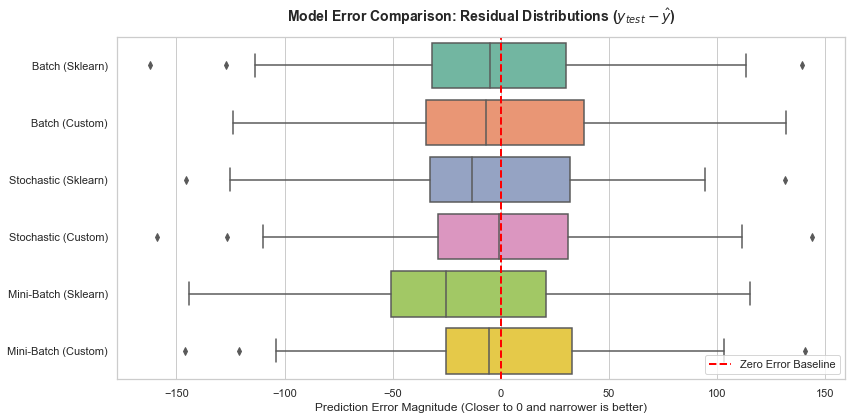

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

residual_data = {
    "Batch (Sklearn)": y_test - y_pred_sk,
    "Batch (Custom)": y_test - y_pred_cust,
    "Stochastic (Sklearn)": y_test - y_pred_sk_sgd,
    "Stochastic (Custom)": y_test - y_pred_cust_sgd,
    "Mini-Batch (Sklearn)": y_test - y_pred_mbgd_sk,   
    "Mini-Batch (Custom)": y_test - y_predy_mbgd_cust,
}

df_residuals = pd.DataFrame(residual_data)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_residuals, orient="h", palette="Set2")
plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Zero Error Baseline")

plt.title("Model Error Comparison: Residual Distributions ($y_{test} - \hat{y}$)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Prediction Error Magnitude (Closer to 0 and narrower is better)", fontsize=12)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()